In [1]:
import pathlib
import numpy as np
import scipy.sparse
import scipy.io
import pandas as pd
import pickle
import networkx as nx 
import utils.preprocess
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as sklearn_stopwords
from nltk import word_tokenize
from nltk.corpus import stopwords as nltk_stopwords
from utils.data import load_glove_vectors
from nltk.stem import WordNetLemmatizer

In [2]:
from sklearn.feature_extraction.text import CountVectorizer


In [3]:
save_prefix = r'./data/DBLP_processed/graph_split/'
# save_prefix = r'D:\OneDrive\PhD\毕业\OHNN\demo_data\DBLP_processed/'
# read_perfix = 'demo_data/'
read_perfix = r'./data/DBLP/'
num_ntypes = 4

In [4]:

mat = scipy.io.loadmat('DBLP4057_GAT_with_idx.mat')

In [5]:
author_label = pd.read_csv(read_perfix + 'author_label.txt', sep='\t', header=None, names=['author_id', 'label', 'author_name'], keep_default_na=False, encoding='utf-8')
paper_author = pd.read_csv(read_perfix + 'paper_author.txt', sep='\t', header=None, names=['paper_id', 'author_id'], keep_default_na=False, encoding='utf-8')
paper_conf = pd.read_csv(read_perfix + 'paper_conf.txt', sep='\t', header=None, names=['paper_id', 'conf_id'], keep_default_na=False, encoding='utf-8')
paper_term = pd.read_csv(read_perfix + 'paper_term.txt', sep='\t', header=None, names=['paper_id', 'term_id'], keep_default_na=False, encoding='utf-8')
papers = pd.read_csv(read_perfix + 'paper.txt', sep='\t', header=None, names=['paper_id', 'paper_title'], keep_default_na=False, encoding='cp1252')
terms = pd.read_csv(read_perfix + 'term.txt', sep='\t', header=None, names=['term_id', 'term'], keep_default_na=False, encoding='utf-8')
confs = pd.read_csv(read_perfix + 'conf.txt', sep='\t', header=None, names=['conf_id', 'conf'], keep_default_na=False, encoding='utf-8')

In [6]:
glove_dim = 50
glove_vectors = load_glove_vectors(dim=glove_dim)

Loading GloVe pretrained word vectors
Done. 400000 words loaded!


In [7]:
# filter out all nodes which does not associated with labeled authors
labeled_authors = author_label['author_id'].to_list()
paper_author = paper_author[paper_author['author_id'].isin(labeled_authors)].reset_index(drop=True)
valid_papers = paper_author['paper_id'].unique()
papers = papers[papers['paper_id'].isin(valid_papers)].reset_index(drop=True)
paper_conf = paper_conf[paper_conf['paper_id'].isin(valid_papers)].reset_index(drop=True)
paper_term = paper_term[paper_term['paper_id'].isin(valid_papers)].reset_index(drop=True)
valid_terms = paper_term['term_id'].unique()
terms = terms[terms['term_id'].isin(valid_terms)].reset_index(drop=True)

In [8]:
#import nltk
#nltk.set_proxy('http://127.0.0.1:10809')
#nltk.download('wordnet')
#nltk.download('omw-1.4')
#nltk.download('stopwords')
#nltk.download('punkt')

In [9]:
#nltk.download_gui()

In [10]:
# term lemmatization and grouping
lemmatizer = WordNetLemmatizer()
lemma_id_mapping = {}
lemma_list = []
lemma_id_list = []
i = 0
for _, row in terms.iterrows():
    i += 1
    lemma = lemmatizer.lemmatize(row['term'])
    lemma_list.append(lemma)
    if lemma not in lemma_id_mapping:
        lemma_id_mapping[lemma] = row['term_id']
    lemma_id_list.append(lemma_id_mapping[lemma])
terms['lemma'] = lemma_list
terms['lemma_id'] = lemma_id_list

print(terms)
print(paper_term)

term_lemma_mapping = {row['term_id']: row['lemma_id'] for _, row in terms.iterrows()}
lemma_id_list = []
for _, row in paper_term.iterrows():
    lemma_id_list.append(term_lemma_mapping[row['term_id']])
paper_term['lemma_id'] = lemma_id_list

paper_term = paper_term[['paper_id', 'lemma_id']]
paper_term.columns = ['paper_id', 'term_id']
paper_term = paper_term.drop_duplicates()
terms = terms[['lemma_id', 'lemma']]
terms.columns = ['term_id', 'term']
terms = terms.drop_duplicates()

      term_id         term        lemma  lemma_id
0           1          the          the         1
1           2    automatic    automatic         2
2           3  acquisition  acquisition         3
3           4           of           of         4
4           5        proof        proof         5
...       ...          ...          ...       ...
8893    13567      gapprox      gapprox     13567
8894    13568       poetry       poetry     13568
8895    13569       estmax       estmax     13569
8896    13570        zonal        zonal     13570
8897    13571    fractures     fracture     13571

[8898 rows x 4 columns]
        paper_id  term_id
0           7601        7
1           7601        8
2           7601        9
3           7601       10
4           7601       11
...          ...      ...
114268    654269      580
114269    654269      723
114270    654269      902
114271    654269     1653
114272    654269     2229

[114273 rows x 2 columns]


In [11]:
# filter out stopwords from terms
stopwords = sklearn_stopwords.union(set(nltk_stopwords.words('english')))
stopword_id_list = terms[terms['term'].isin(stopwords)]['term_id'].to_list()
paper_term = paper_term[~(paper_term['term_id'].isin(stopword_id_list))].reset_index(drop=True)
terms = terms[~(terms['term'].isin(stopwords))].reset_index(drop=True)

In [14]:
author_label = author_label.sort_values('author_id').reset_index(drop=True)
papers = papers.sort_values('paper_id').reset_index(drop=True)
terms = terms.sort_values('term_id').reset_index(drop=True)
confs = confs.sort_values('conf_id').reset_index(drop=True)

In [15]:
# extract labels of authors
labels = author_label['label'].to_numpy()
print(labels)

[2 2 3 ... 0 0 0]


In [16]:
# build the adjacency matrix for the graph consisting of authors, papers, terms and conferences
# 0 for authors, 1 for papers, 2 for terms, 3 for conferences
dim = len(author_label) + len(papers) + len(terms) + len(confs)
type_mask = np.zeros((dim), dtype=int)
type_mask[len(author_label):len(author_label)+len(papers)] = 1
type_mask[len(author_label)+len(papers):len(author_label)+len(papers)+len(terms)] = 2
type_mask[len(author_label)+len(papers)+len(terms):] = 3

author_id_mapping = {row['author_id']: i for i, row in author_label.iterrows()}
paper_id_mapping = {row['paper_id']: i + len(author_label) for i, row in papers.iterrows()}
term_id_mapping = {row['term_id']: i + len(author_label) + len(papers) for i, row in terms.iterrows()}
conf_id_mapping = {row['conf_id']: i + len(author_label) + len(papers) + len(terms) for i, row in confs.iterrows()}

adjM = np.zeros((dim, dim), dtype=int)
for _, row in paper_author.iterrows(): 
    idx1 = paper_id_mapping[row['paper_id']]
    idx2 = author_id_mapping[row['author_id']]
    adjM[idx1, idx2] = 1
    adjM[idx2, idx1] = 1
for _, row in paper_term.iterrows():
    idx1 = paper_id_mapping[row['paper_id']]
    idx2 = term_id_mapping[row['term_id']]
    adjM[idx1, idx2] = 1
    adjM[idx2, idx1] = 1
for _, row in paper_conf.iterrows():
    idx1 = paper_id_mapping[row['paper_id']]
    idx2 = conf_id_mapping[row['conf_id']]
    adjM[idx1, idx2] = 1
    adjM[idx2, idx1] = 1
print(adjM)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [17]:
# use HAN paper's preprocessed data as the features of authors (https://github.com/Jhy1993/HAN)

features_author = np.array(list(zip(*sorted(zip(labeled_authors, mat['features']), key=lambda tup: tup[0])))[1])
features_author = scipy.sparse.csr_matrix(features_author)

In [18]:
# use bag-of-words representation of paper titles as the features of papers
class LemmaTokenizer:
    def __init__(self):
        self.wnl = WordNetLemmatizer()
    def __call__(self, doc):
        return [self.wnl.lemmatize(t) for t in word_tokenize(doc)]
vectorizer = CountVectorizer(min_df=2, stop_words=stopwords, tokenizer=LemmaTokenizer())
features_paper = vectorizer.fit_transform(papers['paper_title'].values)

d:\anaconda3\envs\ohnn\lib\site-packages\sklearn\feature_extraction\text.py:401: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'d", "'ll", "'re", "'s", "'ve", 'doe', 'ha', 'le', "n't", 'need', 'sha', 'u', 'wa', 'wo'] not in stop_words.
  % sorted(inconsistent)


In [19]:
# use pretrained GloVe vectors as the features of terms 
features_term = np.zeros((len(terms), glove_dim))
for i, row in terms.iterrows():
    features_term[i] = glove_vectors.get(row['term'], glove_vectors['the'])

In [20]:
author_label.to_csv(save_prefix + 'author_label.csv')
author_label.head(3)

,author_id,label,author_name
0,192,2,David Hogg
1,226,2,Martial Hebert
2,234,3,Gady Agam


In [21]:
papers.to_csv(save_prefix + 'papers.csv')
papers.head(3)

,paper_id,paper_title
0,7601,Some Philosophical Problems with Formal Learni...
1,7604,Terminological Cycles in KL-ONE-based Knowledg...
2,7605,Integrating Description Logics and Action Form...


In [22]:
terms.to_csv(save_prefix + 'terms.csv')
terms.head(3)

,term_id,term
0,2,automatic
1,3,acquisition
2,5,proof


In [23]:
confs.to_csv(save_prefix + 'confs.csv')
confs.head(3)

,conf_id,conf
0,36,AAAI
1,597,CIKM
2,755,CVPR


In [24]:
len(author_label)

4057

In [25]:
ontology = {
    'stem':[0,1,3],
    'branch':{0:[1,2]}
}

In [26]:
import scipy.sparse
adj = scipy.sparse.lil_matrix(adjM)
raw_dims = [sum(type_mask==p) for p in range(num_ntypes)]
dim = sum(raw_dims)
print(raw_dims)
print(dim)
prefix_operator = np.ones((len(raw_dims)+1, len(raw_dims)))
prefix_operator = np.tril(prefix_operator, k=-1)   # 下三角矩阵
prefix_operator = prefix_operator.dot(raw_dims).astype(int)
print(prefix_operator)
np.save(save_prefix + 'prefix_operator.npy',prefix_operator)

[4057, 14328, 7723, 20]
26128
[    0  4057 18385 26108 26128]


In [27]:
import time

In [28]:
ontology = {
    'stem':[0,1,3],
    'branch':{0:[1,2]}
}
t = time.time()
link_intances = utils.preprocess.get_intances_by_pair(adj, type_mask, ontology, prefix_operator)
#print(link_intances)

subgraphs = utils.preprocess.get_ontology_subgraphs_v3(ontology, link_intances)
print(time.time()-t)
subgraphs = subgraphs[subgraphs.columns.sort_values()]
print(len(subgraphs))
print(subgraphs)
print('=======done=======')
# 0.5s

# cost about 10m 36s with v1
# 7205
# stem 19645
# branch 85815 85810


0.3026442527770996
118195
         0      1      2      3
0      414  14107  18415  26123
1      414  14107  18446  26123
2      414  14107  18778  26123
3      414  14107  19073  26123
4      414  14107  19523  26123
...    ...    ...    ...    ...
9482  1751   5885  18570  26109
9483  1751   5885  18827  26109
9484  1751   5885  18846  26109
9485  1751   5885  20210  26109
9486  1751   5885  20211  26109

[118195 rows x 4 columns]
=======done=======


In [32]:
ontology = {
    'stem':[0,1,3],
    'branch':{0:[1,2]}
}
subgraphs = utils.preprocess.get_ontology_subgraphs_v2(ontology, link_intances)
subgraphs = subgraphs[subgraphs.columns.sort_values()]
print(len(subgraphs))
print(subgraphs)
# cost 19s
# totally 118200 rows

118195
           0      1      2      3
0          0   6421  18386  26110
1          0   6421  18453  26110
2          0   6421  18719  26110
3          0   6421  18837  26110
4          0   6421  18890  26110
...      ...    ...    ...    ...
118193  4056  17949  18789  26125
118194  4056  17949  18833  26125
118195  4056  17949  19381  26125
118196  4056  17949  20193  26125
118197  4056  17949  22436  26125

[118195 rows x 4 columns]


In [33]:
subgraphs.columns.sort_values()
subgraphs[subgraphs.columns.sort_values()]

,0,1,2,3
0,0,6421,18386,26110
1,0,6421,18453,26110
2,0,6421,18719,26110
3,0,6421,18837,26110
4,0,6421,18890,26110
...,...,...,...,...
118193,4056,17949,18789,26125
118194,4056,17949,18833,26125
118195,4056,17949,19381,26125
118196,4056,17949,20193,26125


In [34]:
ontology_subgraphs = [utils.preprocess.row2graph_v2(adjM,row) for row in subgraphs.values]
# cost 5s

AdjacencyView({0: {6421: {}}, 6421: {0: {}, 18386: {}, 26110: {}}, 18386: {6421: {}}, 26110: {6421: {}}})

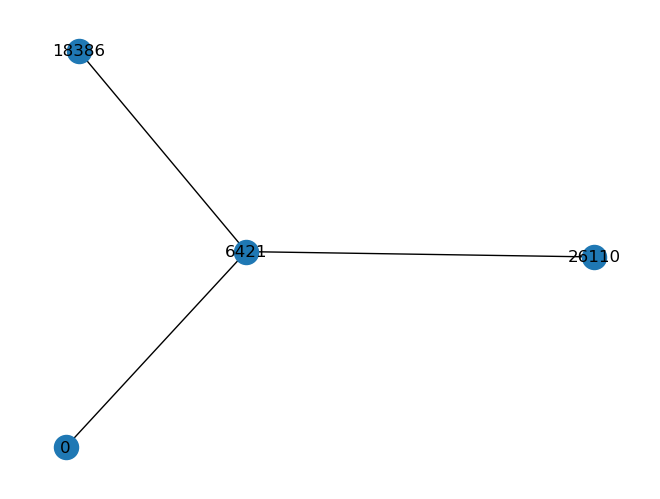

In [29]:
row = subgraphs.values[0]
g = nx.Graph()
g.add_nodes_from(row)
pair = np.argwhere(adjM[row][:,row] == True)
edge_list = [(row[h],row[t]) for h,t in pair]
g.add_edges_from(edge_list)
nx.draw(g, with_labels = True)
g.adj

In [30]:
# mapping of node to subgraphs and mapping of node to node pairs
node_ontology, node_ontology_pairs = utils.preprocess.get_node_ontology_dict(adjM, ontology_subgraphs, subgraphs)

print(len(node_ontology))
print(len(node_ontology_pairs))

# cost 51s
# 26127
# no 6769

26127
26127


In [32]:
res_adj = utils.preprocess.find_res_adj(adjM, subgraphs)
# tmp_g = nx.from_numpy_matrix(res_adj,create_using=nx.Graph)
# nx.draw(tmp_g, with_labels = True)


In [33]:
ontology_pairs = [[0,1],[1,2],[1,3]]


In [34]:
incomplete_ontology_subgraphs, incomplete_subgraphs = utils.preprocess.find_incomplete_subgraph(adjM, type_mask, ontology_pairs, res_adj)
print(len(incomplete_ontology_subgraphs))
print(incomplete_subgraphs)
# 21s
# 3

length 2 detected
length 2 detected
length 2 detected
3
[[449, 6769, 26111], [527, 6769, 26111], [2889, 6769, 26111]]


In [35]:
ontology_tmp = nx.Graph()
ontology_tmp.add_nodes_from(list(set(type_mask)))
ontology_tmp.add_edges_from(ontology_pairs)
ontology_path = {}
for h in ontology_tmp.nodes:
    for t in ontology_tmp.nodes:
        if h == t:
            continue
        tmp = [p for p in nx.all_shortest_paths(ontology_tmp,h,t)]
        path = []
        for i in range(len(tmp[0])-1):
            path.append((tmp[0][i],tmp[0][i+1]))
        ontology_path[(tmp[0][0],tmp[0][-1])] = path
ontology_path

{(0, 1): [(0, 1)],
 (0, 2): [(0, 1), (1, 2)],
 (0, 3): [(0, 1), (1, 3)],
 (1, 0): [(1, 0)],
 (1, 2): [(1, 2)],
 (1, 3): [(1, 3)],
 (2, 0): [(2, 1), (1, 0)],
 (2, 1): [(2, 1)],
 (2, 3): [(2, 1), (1, 3)],
 (3, 0): [(3, 1), (1, 0)],
 (3, 1): [(3, 1)],
 (3, 2): [(3, 1), (1, 2)]}

In [36]:
subgraphs = subgraphs.values

In [82]:
# create the directories if they do not exist
for i in ['complete','incomplete']:
    pathlib.Path(save_prefix + '{}'.format(i)).mkdir(parents=True, exist_ok=True)

# save data 
# networkx graph (ontology subgraphs)
for G in ontology_subgraphs:
    nx.write_adjlist(G, save_prefix + 'complete/complete_subgraph.adjlist')
for G in incomplete_ontology_subgraphs:
    nx.write_adjlist(G, save_prefix + 'incomplete/incomplete_subgraph.adjlist')
# mapping of node to subgraphs
np.save(save_prefix + 'complete/node_ontology.npy', node_ontology, allow_pickle= True)
# mapping of node to node pairs 
np.save(save_prefix + 'complete/node_ontology_pairs.npy', node_ontology_pairs, allow_pickle= True) 
# save schema
np.save(save_prefix + 'complete/ontology.npy', ontology) # schema
np.save(save_prefix + 'incomplete/ontology_pairs.npy', ontology_pairs) # schema
# subgraph table
np.save(save_prefix + 'complete/subgraphs.npy', subgraphs)


0.3030669656076822
0.09650154405854731
0.6004314903337704


In [35]:

# subgraphs train/validation/test splits
rand_seed = 33333333
train_val_idx, test_idx = train_test_split(np.arange(len(adjM)), test_size=0.1, random_state=rand_seed)
a = np.isin(subgraphs,test_idx)
a = a.sum(axis=1).astype('bool')
subgraphs_test = subgraphs[a]
subgraphs_tr_val = subgraphs[~a]
subgraphs[a].shape
print(subgraphs_test.shape[0]/len(subgraphs)) # 30% for test
train_idx, val_idx = train_test_split(train_val_idx, test_size=0.025, random_state=rand_seed)
b = np.isin(subgraphs_tr_val,val_idx)
b = b.sum(axis=1).astype('bool')
subgraphs_val = subgraphs_tr_val[b]
subgraphs_train = subgraphs_tr_val[~b]
subgraphs_tr_val[b].shape
print(subgraphs_val.shape[0]/len(subgraphs)) # 10% for val
print(len(subgraphs_train)/len(subgraphs)) # 60% for train
 


0.3030669656076822
0.09650154405854731
0.6004314903337704


In [49]:
test_node = np.unique(test_idx)
test_node

array([    7,    15,    33, ..., 26099, 26101, 26112])

In [50]:
adjM.sum()

239566

In [54]:
adjM[test_node].sum()/adjM.sum()

0.10438042126178172

In [55]:
adjM[np.unique(val_idx)].sum()/adjM.sum()

0.02181862200813137

In [56]:
adjM[np.unique(train_idx)].sum()/adjM.sum()

0.873800956730087

In [57]:
adjM[np.unique(val_idx)].sum()/adjM.sum()

0.02181862200813137

In [44]:
cnt = 0
for node in test_node:
    cnt += sum(adjM[node])
print(cnt/239566)

1.2522645116585826e-05


In [ ]:
np.savez(save_prefix + 'complete/' + 'subgraphs_train_val_test.npz',
         subgraphs_train=subgraphs_train,
         subgraphs_val=subgraphs_val,
         subgraphs_test=subgraphs_test) # subgraph train&val&test
# node split
np.savez(save_prefix + 'complete/' + 'train_val_test_nodes.npz',
         train_nodes=train_idx,
         val_nodes=val_idx,
         test_nodes=test_idx) # nodes train&val&test

# save basic relation and composite relation
np.save(save_prefix + 'ontology_path.npy', ontology_path, allow_pickle= True)
np.save(save_prefix + 'ontology_pairs.npy', ontology_pairs, allow_pickle= True)
# save data
# all nodes adjacency matrix
scipy.sparse.save_npz(save_prefix + 'adjM.npz', scipy.sparse.csr_matrix(adjM))
# all nodes (authors, papers, terms and conferences) features
# currently only have features of authors, papers and terms
scipy.sparse.save_npz(save_prefix + 'features_{}.npz'.format(0), features_author)
scipy.sparse.save_npz(save_prefix + 'features_{}.npz'.format(1), features_paper)
np.save(save_prefix + 'features_{}.npy'.format(2), features_term)
# all nodes (authors, papers, terms and conferences) type labels
np.save(save_prefix + 'node_types.npy', type_mask)
# author labels
np.save(save_prefix + 'labels.npy', labels)

# author train/validation/test splits
rand_seed = 33333333
author_train_idx, author_val_idx = train_test_split(np.arange(len(labels)), test_size=0.1, random_state=rand_seed)
author_train_idx, author_test_idx = train_test_split(author_train_idx, test_size=int(len(labels)*0.8), random_state=rand_seed)
author_train_idx.sort()
author_val_idx.sort()
author_test_idx.sort()
a = np.isin(subgraphs,author_test_idx)
a = a.sum(axis=1).astype('bool')
author_subgraphs_test = subgraphs[a]
b = np.isin(subgraphs,author_val_idx)
b = b.sum(axis=1).astype('bool')
author_subgraphs_val = subgraphs[b]
c = np.isin(subgraphs,author_train_idx)
c = c.sum(axis=1).astype('bool')
author_subgraphs_train = subgraphs[c]

np.savez(save_prefix + 'complete/' + 'author_train_val_test_idx.npz',
         author_train_idx=author_train_idx, # 10%
         author_val_idx=author_val_idx, # 10%
         author_test_idx=author_test_idx) #80%
np.savez(save_prefix + 'complete/' + 'author_subgraphs_train_val_test_idx.npz',
         author_subgraphs_train=author_subgraphs_train, # 9%
         author_subgraphs_val=author_subgraphs_val, # 11%
         author_subgraphs_test=author_subgraphs_test) # 80%


In [147]:
ontology_pairs

[[0, 1], [1, 2], [1, 3]]

In [34]:
subgraphs = np.load(r'F:\Data\OHNN\data\DBLP_processed\whole2\complete\ontology_subgraphs.npy')
len(subgraphs)

118195

In [131]:
# author train/validation/test splits
rand_seed = 33333333
train_val_idx, test_idx = train_test_split(np.arange(len(adjM)), test_size=0.1, random_state=rand_seed)
a = np.isin(subgraphs,test_idx)
a = a.sum(axis=1).astype('bool')
subgraphs_test = subgraphs[a]
subgraphs_tr_val = subgraphs[~a]
subgraphs[a].shape


(35821, 4)

In [132]:
subgraphs_test.shape[0]/len(subgraphs) # 30% for test

0.3030669656076822

In [133]:
subgraphs[~a].shape

(82374, 4)

In [149]:
rand_seed = 33333333
train_idx, val_idx = train_test_split(train_val_idx, test_size=0.025, random_state=rand_seed)
b = np.isin(subgraphs_tr_val,val_idx)
b = b.sum(axis=1).astype('bool')

subgraphs_val = subgraphs_tr_val[b]
subgraphs_train = subgraphs_tr_val[~b]
subgraphs_tr_val[b].shape

(11406, 4)

In [157]:
subgraphs_val.shape[0]/len(subgraphs) # 10% for val
len(subgraphs_train)/len(subgraphs) # 60% for train

0.6004314903337704

In [ ]:

train_idx, test_idx = train_test_split(train_idx, test_size=3257, random_state=rand_seed)
train_idx.sort()
val_idx.sort()
test_idx.sort()
np.savez(save_prefix + 'train_val_test_idx.npz',
         val_idx=val_idx,
         train_idx=train_idx,
         test_idx=test_idx)

In [ ]:
# post-processing for mini-batched training
target_idx_list = np.arange(4057)
for metapath in [(0, 1, 0), (0, 1, 2, 1, 0), (0, 1, 3, 1, 0)]:
    edge_metapath_idx_array = np.load(save_prefix + '{}/'.format(0) + '-'.join(map(str, metapath)) + '_idx.npy')
    target_metapaths_mapping = {}
    for target_idx in target_idx_list:
        target_metapaths_mapping[target_idx] = edge_metapath_idx_array[edge_metapath_idx_array[:, 0] == target_idx][:, ::-1]
    out_file = open(save_prefix + '{}/'.format(0) + '-'.join(map(str, metapath)) + '_idx.pickle', 'wb')
    pickle.dump(target_metapaths_mapping, out_file)
    out_file.close()

=========以下忽略==============================================================

In [54]:
# author train/validation/test splits
rand_seed = 33333333
train_idx, val_idx = train_test_split(np.arange(len(adjM)), test_size=0.4, random_state=rand_seed)
val_idx, test_idx = train_test_split(val_idx, test_size=0.75, random_state=rand_seed)

conf_id = np.where(type_mask == 3)[0] # conference only 20

train_idx = np.hstack((train_idx,conf_id))
val_idx = np.hstack((val_idx,conf_id))
# test_idx = np.hstack((test_idx,conf_id))

train_idx = np.unique(train_idx)
val_idx = np.unique(val_idx)
test_idx = np.unique(test_idx)
np.savez(save_prefix + 'split/' + 'train_val_test_idx_pure_test.npz',
         val_idx=val_idx,
         train_idx=train_idx,
         test_idx=test_idx)

In [43]:
a = np.load(r'F:\Data\OHNN\data\DBLP_processed\split' + '/train_val_test_idx.npz')
val = a['val_idx']
train = a['train_idx']
test = a['test_idx']


In [68]:
test_idx[np.where(test_idx >= conf_id[0])]

array([26126, 26127])

In [55]:
idx = val_idx
type_mask1 = type_mask[idx]
type_mask1.shape

print(idx[type_mask1 == 0].shape)

feat0 = features_author[idx[type_mask1 == 0]]
feat1 = features_paper[idx[type_mask1 == 1] - features_author.shape[0]]
feat2 = features_term[idx[type_mask1 == 2] - features_author.shape[0] - features_paper.shape[0]]

(430,)


In [57]:
def data_split(idx, save_prefix, type ='train', adjM = adjM, type_mask_raw = type_mask, features_author = features_author, features_paper = features_paper, features_term = features_term):
    ontology = {
        'stem':[0,1,3],
        'branch':{0:[1,2]}
    }
    ontology_pairs = [[0,1],[1,2],[1,3]]

    if type == 'train':
        save_prefix = save_prefix + r'split_pure_test/train/'
    if type == 'val':
        save_prefix = save_prefix + r'split_pure_test/val/'
    if type == 'test':
        save_prefix = save_prefix + r'split_pure_test/test/'
    
    
    adjM = adjM[np.ix_(idx,idx)]
    type_mask = type_mask_raw[idx]
    
    feat0 = features_author[idx[type_mask == 0]]
    feat1 = features_paper[idx[type_mask == 1] - features_author.shape[0]]
    feat2 = features_term[idx[type_mask == 2] - features_author.shape[0] - features_paper.shape[0]]

    
    link_intances = utils.preprocess.get_intances(adjM, type_mask, ontology)
    #print(link_intances)
    print('=======done=======')
    print(len(link_intances['stem']))
    print(len(link_intances['branch'][0]))
    subgraphs = utils.preprocess.get_ontology_subgraphs_v2(ontology, link_intances)
    subgraphs = subgraphs[subgraphs.columns.sort_values()]
    print('len subgraphs: ',len(subgraphs))
    subgraphs.columns.sort_values()
    subgraphs[subgraphs.columns.sort_values()]
    ontology_subgraphs = [utils.preprocess.row2graph_v2(adjM,row) for row in subgraphs.values]
    node_ontology, node_ontology_pairs = utils.preprocess.get_node_ontology_dict(adjM, ontology_subgraphs, subgraphs)
    print(len(node_ontology))
    print(len(node_ontology_pairs))
    # res_adj = utils.preprocess.find_res_adj(adjM, subgraphs)
    # print('res_adj found')
    # incomplete_ontology_subgraphs, incomplete_subgraphs = utils.preprocess.find_incomplete_subgraph(adjM, type_mask, ontology_pairs, res_adj)
    # print(len(incomplete_ontology_subgraphs))
    # print(incomplete_subgraphs)
    ontology_tmp = nx.Graph()
    ontology_tmp.add_nodes_from(list(set(type_mask)))
    ontology_tmp.add_edges_from(ontology_pairs)
    ontology_path = {}
    for h in ontology_tmp.nodes:
        for t in ontology_tmp.nodes:
            if h == t:
                continue
            tmp = [p for p in nx.all_shortest_paths(ontology_tmp,h,t)]
            path = []
            for i in range(len(tmp[0])-1):
                path.append((tmp[0][i],tmp[0][i+1]))
            ontology_path[(tmp[0][0],tmp[0][-1])] = path
    ontology_path

    # create the directories if they do not exist
    for i in ['complete','incomplete']:
        pathlib.Path(save_prefix + '{}'.format(i)).mkdir(parents=True, exist_ok=True)

    # save data 
    # networkx graph (ontology subgraphs)
    for G in ontology_subgraphs:
        nx.write_adjlist(G, save_prefix + 'complete/complete_subgraph.adjlist')
    # for G in incomplete_ontology_subgraphs:
    #     nx.write_adjlist(G, save_prefix + 'incomplete/incomplete_subgraph.adjlist')
    # mapping of node to subgraphs
    np.save(save_prefix + 'complete/node_ontology.npy', node_ontology, allow_pickle= True)
    # mapping of node to node pairs 
    np.save(save_prefix + 'complete/node_ontology_pairs.npy', node_ontology_pairs, allow_pickle= True) 
    # save schema
    np.save(save_prefix + 'complete/ontology.npy', ontology) # schema
    np.save(save_prefix + 'incomplete/ontology_pairs.npy', ontology_pairs) # schema
    np.save(save_prefix + 'complete/ontology_subgraphs.npy', subgraphs.values) # subgraph table
    # save basic relation and composite relation
    np.save(save_prefix + 'ontology_path.npy', ontology_path, allow_pickle= True)
    np.save(save_prefix + 'ontology_pairs.npy', ontology_pairs, allow_pickle= True)
    # save data
    # all nodes adjacency matrix
    scipy.sparse.save_npz(save_prefix + 'adjM.npz', scipy.sparse.csr_matrix(adjM))
    # all nodes (authors, papers, terms and conferences) features
    # currently only have features of authors, papers and terms
    scipy.sparse.save_npz(save_prefix + 'features_{}.npz'.format(0), feat0)
    scipy.sparse.save_npz(save_prefix + 'features_{}.npz'.format(1), feat1)
    np.save(save_prefix + 'features_{}.npy'.format(2), feat2)
    # all nodes (authors, papers, terms and conferences) type labels
    np.save(save_prefix + 'node_types.npy', type_mask)
    # author labels
    np.save(save_prefix + 'labels.npy', labels[idx[type_mask == 0]])
    # author train/validation/test splits
    
    return len(subgraphs.values)



In [105]:
adjM

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [58]:
data_split(val_idx, save_prefix, type='val', adjM = adjM, type_mask_raw = type_mask, features_author = features_author, features_paper = features_paper, features_term = features_term)
#149


stem searching starts!
branch0 searching starts!
length 2 detected
=======done=======
245
870
len subgraphs:  149
267
267


In [59]:
data_split(test_idx,save_prefix,type='test', adjM = adjM, type_mask_raw = type_mask, features_author = features_author, features_paper = features_paper, features_term = features_term)
# 108

stem searching starts!
branch0 searching starts!
length 2 detected
Tue Mar 14 03:36:59 2023, about 1002 instances have been found, current head node is 1717, tail node is [5718 5754].
Tue Mar 14 03:36:59 2023, about 2005 instances have been found, current head node is 2205, tail node is [5671 5866 5911 6843].
Tue Mar 14 03:36:59 2023, about 3006 instances have been found, current head node is 2686, tail node is [5683 5793 7786].
Tue Mar 14 03:36:59 2023, about 4007 instances have been found, current head node is 3217, tail node is [5576 5764 5780].
Tue Mar 14 03:36:59 2023, about 5008 instances have been found, current head node is 3765, tail node is [5712 5914].
Tue Mar 14 03:36:59 2023, about 6010 instances have been found, current head node is 4299, tail node is [5559 5649].
Tue Mar 14 03:36:59 2023, about 7011 instances have been found, current head node is 4783, tail node is [5557 6112].
Tue Mar 14 03:36:59 2023, about 8013 instances have been found, current head node is 5317, tai

In [69]:
data_split(train_idx,save_prefix,type='train', adjM = adjM, type_mask_raw = type_mask, features_author = features_author, features_paper = features_paper, features_term = features_term)
# 22766

stem searching starts!
Tue Mar 14 03:47:53 2023, about 1001 instances have been found, current head node is 230.
Tue Mar 14 03:48:13 2023, about 2005 instances have been found, current head node is 508.
Tue Mar 14 03:48:34 2023, about 3006 instances have been found, current head node is 838.
Tue Mar 14 03:48:52 2023, about 4007 instances have been found, current head node is 1145.
Tue Mar 14 03:49:11 2023, about 5009 instances have been found, current head node is 1427.
Tue Mar 14 03:49:34 2023, about 6010 instances have been found, current head node is 1904.
branch0 searching starts!
length 2 detected
Tue Mar 14 03:49:50 2023, about 1003 instances have been found, current head node is 2752, tail node is [11164 11558 11605].
Tue Mar 14 03:49:50 2023, about 2005 instances have been found, current head node is 3059, tail node is [11027 11099].
Tue Mar 14 03:49:50 2023, about 3006 instances have been found, current head node is 3335, tail node is [11089 11244].
Tue Mar 14 03:49:50 2023, a

In [96]:
train_adj = adjM[np.ix_(train_idx,train_idx)]
train_adj.shape
train_feat0 = features_author[train_idx[type_mask[train_idx] == 0]]
train_feat1 = features_paper[train_idx[type_mask[train_idx] == 1] - features_author.shape[0]]
train_feat2 = features_term[train_idx[type_mask[train_idx] == 2] - features_author.shape[0] - features_paper.shape[0]]
train_type_mask = type_mask[train_idx]

(15682,)

In [98]:
ontology = {
    'stem':[0,1,3],
    'branch':{0:[1,2]}
}
ontology_pairs = [[0,1],[1,2],[1,3]]


train_link_intances = utils.preprocess.get_intances(train_adj, train_type_mask, ontology)
#print(link_intances)
print('=======done=======')
print(len(link_intances['stem']))
print(len(link_intances['branch'][0]))
train_subgraphs = utils.preprocess.get_ontology_subgraphs_v2(ontology, train_link_intances)
train_subgraphs = train_subgraphs[train_subgraphs.columns.sort_values()]
print('len subgraphs: ',len(train_subgraphs))
train_subgraphs.columns.sort_values()
train_subgraphs[train_subgraphs.columns.sort_values()]
train_ontology_subgraphs = [utils.preprocess.row2graph_v2(train_adj,row) for row in train_subgraphs.values]
train_node_ontology, train_node_ontology_pairs = utils.preprocess.get_node_ontology_dict(train_adj, train_ontology_subgraphs, train_subgraphs)
print(len(train_node_ontology))
print(len(train_node_ontology_pairs))

# train_res_adj = utils.preprocess.find_res_adj(train_adj, train_subgraphs)
# print('res_adj found')
# train_incomplete_ontology_subgraphs, train_incomplete_subgraphs = utils.preprocess.find_incomplete_subgraph(train_adj, train_type_mask, ontology_pairs, train_res_adj)
# print(len(train_incomplete_ontology_subgraphs))
# print('train_incomplete_subgraphs: ', train_incomplete_subgraphs)
ontology_tmp = nx.Graph()
ontology_tmp.add_nodes_from(list(set(train_type_mask)))
ontology_tmp.add_edges_from(ontology_pairs)
ontology_path = {}
for h in ontology_tmp.nodes:
    for t in ontology_tmp.nodes:
        if h == t:
            continue
        tmp = [p for p in nx.all_shortest_paths(ontology_tmp,h,t)]
        path = []
        for i in range(len(tmp[0])-1):
            path.append((tmp[0][i],tmp[0][i+1]))
        ontology_path[(tmp[0][0],tmp[0][-1])] = path
ontology_path

save_prefix = save_prefix + r'split/train/'
# create the directories if they do not exist
for i in ['complete','incomplete']:
    pathlib.Path(save_prefix + '{}'.format(i)).mkdir(parents=True, exist_ok=True)

# save data 
# networkx graph (ontology subgraphs)
for G in train_ontology_subgraphs:
    nx.write_adjlist(G, save_prefix + 'complete/complete_subgraph.adjlist')
# for G in train_incomplete_ontology_subgraphs:
#     nx.write_adjlist(G, save_prefix + 'incomplete/incomplete_subgraph.adjlist')
# mapping of node to subgraphs
np.save(save_prefix + 'complete/node_ontology.npy', train_node_ontology, allow_pickle= True)
# mapping of node to node pairs 
np.save(save_prefix + 'complete/node_ontology_pairs.npy', train_node_ontology_pairs, allow_pickle= True) 
# save schema
np.save(save_prefix + 'complete/ontology.npy', ontology) # schema
np.save(save_prefix + 'incomplete/ontology_pairs.npy', ontology_pairs) # schema
np.save(save_prefix + 'complete/ontology_subgraphs.npy', train_subgraphs.values) # subgraph table
# save basic relation and composite relation
np.save(save_prefix + 'ontology_path.npy', ontology_path, allow_pickle= True)
np.save(save_prefix + 'ontology_pairs.npy', ontology_pairs, allow_pickle= True)
# save data
# all nodes adjacency matrix
scipy.sparse.save_npz(save_prefix + 'adjM.npz', scipy.sparse.csr_matrix(train_adj))
# all nodes (authors, papers, terms and conferences) features
# currently only have features of authors, papers and terms
scipy.sparse.save_npz(save_prefix + 'features_{}.npz'.format(0), train_feat0)
scipy.sparse.save_npz(save_prefix + 'features_{}.npz'.format(1), train_feat1)
np.save(save_prefix + 'features_{}.npy'.format(2), train_feat2)
# all nodes (authors, papers, terms and conferences) type labels
np.save(save_prefix + 'node_types.npy', train_type_mask)
# author labels
np.save(save_prefix + 'labels.npy', labels[train_idx[type_mask[train_idx] == 0]])
# author train/validation/test splits


stem searching starts!
Sun Mar 12 09:03:54 2023, about 1001 instances have been found, current head node is 230.
Sun Mar 12 09:04:23 2023, about 2005 instances have been found, current head node is 508.
Sun Mar 12 09:04:53 2023, about 3006 instances have been found, current head node is 838.
Sun Mar 12 09:05:22 2023, about 4007 instances have been found, current head node is 1145.
Sun Mar 12 09:05:49 2023, about 5009 instances have been found, current head node is 1427.
Sun Mar 12 09:06:21 2023, about 6010 instances have been found, current head node is 1904.
branch0 searching starts!
length 2 detected
Sun Mar 12 09:06:47 2023, about 1003 instances have been found, current head node is 2752, tail node is [11164 11558 11605].
Sun Mar 12 09:06:47 2023, about 2005 instances have been found, current head node is 3059, tail node is [11027 11099].
Sun Mar 12 09:06:47 2023, about 3006 instances have been found, current head node is 3335, tail node is [11089 11244].
Sun Mar 12 09:06:47 2023, a

IndexError: index 4058 is out of bounds for axis 0 with size 4057